# **Baseline Thermodynamic Modeling: The Dynamic Shockley-Queisser Limit**

To understand the limiting performance of a perovskite solar cell, its behavior must be modeled under the **principle of detailed balance**. In this framework, the cell is an open thermodynamic system in constant radiative exchange with the Sun and its environment. While the device absorbs photons to generate electron-hole pairs, the laws of thermodynamics dictate that it must simultaneously emit thermal radiation to maintain equilibrium.

Unlike the classic static Shockley-Queisser (SQ) evaluation, a **2D parametric model** is implemented here. This approach dynamically recalculates the thermodynamic limit at every time step, based on two fluctuating empirical variables collected outdoors: the physical temperature of the device ($T$) and the incident local irradiance ($G$).

---

## **1. The Solar Spectrum and Ideal Photogeneration ($J_{\text{sc, 1sun}}$)**

The computational starting point is the AM1.5G standard solar spectrum. First, the **Total Incident Power** ($P_{\text{in, AM1.5G}}$) is obtained by integrating the spectral irradiance $I_{\text{AM1.5G}}(\lambda)$:

$$P_{\text{in, AM1.5G}} = \int_{0}^{\infty} I_{\text{AM1.5G}}(\lambda) \, d\lambda$$

The cell has an absorption threshold dictated by its bandgap ($E_{\text{g}}$). We transform the irradiance into a spectral photon flux ($\Phi_{\text{photon}}$):

$$\Phi_{\text{photon}}(\lambda) = \frac{I_{\text{AM1.5G}}(\lambda) \cdot \lambda}{hc}$$

The **Ideal Short-Circuit Current** ($J_{\text{sc, 1sun}}$) is calculated by integrating this flux up to the material's cutoff wavelength ($\lambda_{\text{g}} = hc/E_{\text{g}}$):

$$J_{\text{sc, 1sun}} = q \int_{0}^{\lambda_{\text{g}}} \Phi_{\text{photon}}(\lambda) \, d\lambda$$

---

## **2. Dynamic Scaling to Outdoor Conditions ($J_{\text{sc, dynamic}}$)**

The model adjusts photogeneration assuming that empirical irradiance fluctuations ($G_{\text{real}}$) scale the overall intensity:

$$J_{\text{sc, dynamic}} = J_{\text{sc, 1sun}} \cdot \left( \frac{G_{\text{real}}}{P_{\text{in, AM1.5G}}} \right)$$

---

## **3. Radiative Recombination and Thermal Emission ($J_0$)**

The background thermal photon flux ($b_{\text{a}}$) exchanged is governed by **Planck's Law** evaluated at the operating temperature ($T$):

$$b_{\text{a}}(E; T) = \frac{2\pi}{h^3 c^2} \frac{E^2}{\exp \left( \frac{E}{k_{\text{B}} T} \right) - 1}$$

The **Reverse Saturation Current Density** ($J_0$) is obtained by integrating this environmental flux above the bandgap:

$$J_0(T, E_{\text{g}}) = q \int_{E_{\text{g}}}^{\infty} b_{\text{a}}(E; T) \, dE$$

---

## **4. Voltage Limit and Fill Factor ($V_{\text{oc}}$ and $\text{FF}$)**

The maximum **Open-Circuit Voltage** ($V_{\text{oc}}$) is extracted from the ideal diode equation:

$$V_{\text{oc}}(T, G) = \frac{k_{\text{B}} T}{q} \ln \left( 1 + \frac{J_{\text{sc, dynamic}}}{J_0(T, E_{\text{g}})} \right)$$

For the theoretical **Fill Factor** ($\text{FF}$), **M.A. Green's** analytical approximation is used. Defining the normalized voltage ($v_{\text{oc}}$):

$$v_{\text{oc}} = \frac{q V_{\text{oc}}}{k_{\text{B}} T} \quad \implies \quad \text{FF} \approx \frac{v_{\text{oc}} - \ln(v_{\text{oc}} + 0.72)}{v_{\text{oc}} + 1}$$

---

## **5. The Maximum Power Point (MPP) Ceiling**

The real-time **Maximum Theoretical Efficiency** ($\eta_{\text{max}}$) and **Ideal Predicted Power** ($P_{\text{pred}}$) are:

$$\eta_{\text{max}}(T, G) = \frac{J_{\text{sc, dynamic}} \cdot V_{\text{oc}} \cdot \text{FF}}{G_{\text{real}}}$$

$$P_{\text{pred}} = G_{\text{real}} \times \eta_{\text{max}}(T, G)$$

---

## **6. The Performance Ratio ($\text{PR}$)**

The direct ratio between the experimentally extracted power ($P_{\text{real}}$) and the predicted maximum theoretical limit ($P_{\text{pred}}$) defines the device's health diagnostic:

$$\text{Performance Ratio (PR)} = \frac{P_{\text{real}}}{P_{\text{pred}}}$$

Unlike measuring only raw power, this metric isolates the true intrinsic degradation of the material by normalizing performance, discounting natural irradiance variations throughout the day. A system in perfect condition will maintain a constant PR (close to $1.0$ or $100\%$), so a progressive decline in this index irrefutably evidences structural loss in the cell's conversion capacity.

In [1]:
import os

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.constants import c, e as q
from scipy.constants import h
from scipy.constants import k as k_B
from scipy.integrate import simpson

 **Data Loading**

In [2]:
df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/Features/df_features.parquet')
df = df.rename(columns={
    'power_cell_mwcm2': 'mpp_mwcm2',
    'local_irradiance_mwcm2': 'G_mwcm2',
    'irradiance_30_degrees_mwcm2': 'cams_mwcm2',
})
df_0 = df.copy()

In [3]:
df_0.columns

Index(['level_0', 'time', 'cell_id', 'mpp_mwcm2', 'power_art', 'G_mwcm2',
       'local_irradiance_art', 'smooth_local_irradiance_mwcm2',
       'hour_fraction', 'hour_sin', 'hour_cos', 'cams_mwcm2',
       'cams_irradiance_art', 'irradiance_30_degrees_is_linreg', 'DeviceTemp',
       't_chamber', 'AmbientTemp', 'Humidity', 'index', 'id_curve',
       'label_curve', 'ff_fwd', 'ff_rev', 'jsc_fwd', 'jsc_rev', 'p_mpp_fwd',
       'p_mpp_rev', 'time_fwd', 'time_rev', 'v_mpp_fwd', 'v_mpp_rev',
       'voc_fwd', 'voc_rev', 'time_avg', 'is_ffill', 'pce', 'power_STC_mwcm2',
       'gci', 'hysteresis_index', 'Delta_P_ion'],
      dtype='object')

**Auxiliary and Physical Functions**

In [4]:
def get_cell_df(df_in, cell_id):
    """Filters the dataframe by cell ID and returns its nomenclature."""
    cell_df = df_in[df_in['cell_id'] == cell_id].copy()
    cell = 'M0' if cell_id == 0 else 'P12'
    return cell_df, cell

def blackbody_flux(E_val, Temp):
    """Calculates the photon flux emitted as a blackbody using Planck's Law."""
    return (2 * np.pi / (h**3 * c**2)) * (E_val**2) / (np.exp(E_val / (k_B * Temp)) - 1)

def calculate_eta_max_T_G(T_cell_K, G_real_mwcm2, J_sc_1sun, E_g_J, P_in_AM15_W_m2):
    """
    Calculates the dynamic 2D thermodynamic limit (Shockley-Queisser), based on the real cell temperature (T_cell) and real irradiance (G).
    """
    # 1. Scale empirical irradiance to W/m2 (1 mW/cm2 = 10 W/m2)
    G_real_W_m2 = G_real_mwcm2 * 10.0
    intensity_ratio = G_real_W_m2 / P_in_AM15_W_m2

    # If it is night or there is no measurable light, theoretical efficiency is 0
    if intensity_ratio <= 0:
        return 0.0

    # 2. Scale J_sc linearly with light intensity
    J_sc_dynamic = J_sc_1sun * intensity_ratio

    # 3. Thermal emission (J_0) that depends ONLY on temperature
    E_abs = np.linspace(E_g_J, 6 * q, 2000)
    J_0 = q * simpson(blackbody_flux(E_abs, T_cell_K), E_abs)

    # 4. Logarithmic drop of V_oc and FF due to light and temperature
    V_oc = (k_B * T_cell_K / q) * np.log(1 + J_sc_dynamic / J_0)
    v_oc = q * V_oc / (k_B * T_cell_K)
    FF = (v_oc - np.log(v_oc + 0.72)) / (v_oc + 1)

    # 5. Limit efficiency
    eta_max = (J_sc_dynamic * V_oc * FF) / G_real_W_m2
    return eta_max * 100

**Main Processing**

In [5]:
def level_0(df_in, J_sc_ideal, E_g_J, P_in_AM15, cell_id=0, min_G_mwcm2=0):
    print(f"Starting Level 0 for cell_id={cell_id}. Applying Dynamic 2D SQ Model (T & G)...")

    cell_df, cell_name = get_cell_df(df_in, cell_id)
    if 'time' in cell_df.columns:
        cell_df.set_index('time', inplace=True)
    cell_df.sort_index(inplace=True)

    mask = (cell_df['G_mwcm2'] > min_G_mwcm2) & (cell_df['DeviceTemp'].notna())
    if not mask.any():
        return cell_df.reset_index() if 'time' in cell_df.index.names else cell_df

    print(f"Calculating dynamic theoretical efficiencies for {cell_name}...")

    # Row-by-row 2D application
    theoretical_eta_fraction = cell_df.loc[mask].apply(
        lambda row: calculate_eta_max_T_G(
            T_cell_K=(row['DeviceTemp'] + 273.15),
            G_real_mwcm2=row['G_mwcm2'],
            J_sc_1sun=J_sc_ideal,
            E_g_J=E_g_J,
            P_in_AM15_W_m2=P_in_AM15
        ), axis=1
    ) / 100.0

    # Raw modeled power (Theoretical SQ limit without losses)
    mpp_pred_full = cell_df.loc[mask, 'G_mwcm2'] * theoretical_eta_fraction

    # =========================================================================
    # Synchronous Normalization using Isolated Power (Isolated MPP)
    # =========================================================================
    # 1. Temporarily calculate the isolated curve to find clean peaks
    isolated_temp = cell_df['mpp_mwcm2'].rolling(window='4min', min_periods=1, center=False).max()

    # 2. Filter indices where we have valid data in the mask
    valid_idx = cell_df.loc[mask].dropna(subset=['mpp_mwcm2']).index

    if len(valid_idx) > 0:
        # 3. Find the top 0.5% based on the ISOLATED curve (not the raw one)
        isolated_max_threshold = isolated_temp.loc[valid_idx].quantile(0.995)
        best_moments_idx = valid_idx[isolated_temp.loc[valid_idx] >= isolated_max_threshold]

        # 4. Calculate the ratio (Isolated / Theoretical) at those exact moments
        ratios = isolated_temp.loc[best_moments_idx] / mpp_pred_full.loc[best_moments_idx]

        # 5. Take the median to set the scaling factor
        scale_factor = ratios.median()

        print(f"--> Synchronously normalizing {cell_name} with respect to the isolated curve:")
        print(f"--> Applied scaling factor: {scale_factor:.4f}")
        mpp_pred_full = mpp_pred_full * scale_factor
    # =========================================================================

    if 'mpp_pred_mwcm2' not in cell_df.columns:
        cell_df['mpp_pred_mwcm2'] = np.nan

    cell_df.loc[mask, 'mpp_pred_mwcm2'] = mpp_pred_full
    cell_df.loc[cell_df['G_mwcm2'] <= 0, 'mpp_pred_mwcm2'] = 0
    cell_df['mpp_pred_mwcm2'] = cell_df['mpp_pred_mwcm2'].clip(lower=0)

    if 'index' in cell_df.columns:
        cell_df = cell_df.drop('index', axis=1)

    print(f"--- Theoretical dynamic process finished for cell {cell_name} ---")
    return cell_df.reset_index().sort_values(by=['time'], ascending=[True])

**Visualization Function**

In [6]:
def plot_profile(df_plot_in, cell_id=0, min_gci=0.9, min_G_mwcm2=60, min_power=6.0,
                 isolated_mpp_line=True, start_date=None, end_date=None, color=True,
                 temp=True, feature=None, theoretical=False, PR=False, df_window=500):

    # 1. Check for mutually exclusive arguments on the secondary y-axis
    active_right_axes = sum([temp, (feature is not None), PR])
    if active_right_axes > 1:
        print('[ERROR] Mutually exclusive usage: "temp", "feature", and "PR" cannot be defined simultaneously. Choose only one for the right y-axis.')
        return

    # 2. Filter by cell ID
    cell_df = df_plot_in[df_plot_in['cell_id'] == cell_id].copy()

    if cell_df.empty:
        print(f"Error: No data found for cell_id {cell_id}.")
        return

    # 3. Define Labels & Metrics
    cell_name = 'M0' if cell_id == 0 else 'P12'
    power = 'mpp_mwcm2'
    metric_name = "Pmpp"
    unit = "mW/cm$^2$"

    # 4. Apply initial data masks (Clear sky conditions & valid power)
    mask_clear = (cell_df['gci'] > min_gci) & \
                 (cell_df['cams_mwcm2'] > min_G_mwcm2) & \
                 (cell_df[power] > min_power)

    cell_df_clear = cell_df[mask_clear].copy()

    # 5. Handle Datetime Index
    if 'time' in cell_df_clear.columns:
        cell_df_clear.set_index('time', inplace=True)
    elif cell_df_clear.index.name != 'time':
        print("Warning: Index is not named 'time' and 'time' column not found.")

    if start_date is not None or end_date is not None:
        cell_df_clear.index = pd.to_datetime(cell_df_clear.index)
        if start_date:
            cell_df_clear = cell_df_clear[cell_df_clear.index >= pd.to_datetime(start_date)]
        if end_date:
            cell_df_clear = cell_df_clear[cell_df_clear.index <= pd.to_datetime(end_date)]

    if cell_df_clear.empty:
        print(f"Error: No data meets the filter criteria for cell {cell_name} in the specified dates.")
        return

    # Calculate days passed for the colormap
    days_passed = (cell_df_clear.index - cell_df_clear.index.min()).total_seconds() / (24 * 3600)

    if isolated_mpp_line and 'isolate_mpp_mwcm2' not in cell_df_clear.columns:
        cell_df_clear['isolate_mpp_mwcm2'] = cell_df_clear[power].rolling(window='4min', min_periods=1, center=False).max()

    # 6. Performance Ratio (Experimental Power / Theoretical SQ limit)
    if PR:
        if 'mpp_pred_mwcm2' in cell_df_clear.columns:
            # Calculate PR and handle division by near-zero values at sunset/sunrise
            # Clip at 1.5 to avoid mathematical artifacts spiking the graph
            cell_df_clear['pr_raw'] = cell_df_clear['isolate_mpp_mwcm2'] / cell_df_clear['mpp_pred_mwcm2'].replace(0, np.nan)
            cell_df_clear['pr_raw'] = cell_df_clear['pr_raw'].clip(lower=0, upper=1.5)
        else:
            print("Warning: 'mpp_pred_mwcm2' column not found. Cannot calculate Performance Ratio.")
            PR = False

    # =========================================================================
    # TEMPORAL PLOT (Evolution over days)
    # =========================================================================
    if temp or (feature is not None) or theoretical or PR:
        df_plot = cell_df_clear.copy().reset_index()
        idx_x = df_plot.index

        fig, ax1 = plt.subplots(figsize=(16, 9))

        # --- Scatter plot for Raw Power ---
        if color:
            sc = ax1.scatter(idx_x, df_plot[power], c=days_passed, cmap='coolwarm', alpha=0.5, s=10, label=f'{metric_name} (Raw)')
            cbar = fig.colorbar(sc, ax=ax1, pad=0.1)
            cbar.set_label('Days since start', rotation=270, labelpad=20, fontsize=14)
            cbar.ax.tick_params(labelsize=12)
        else:
            ax1.scatter(idx_x, df_plot[power], alpha=0.5, s=10, label=f'{metric_name} (Raw)')

        ax1.tick_params(axis='y', labelcolor='black', labelsize=12)
        ax1.set_ylabel(f'{metric_name} ({unit})', color='black', fontsize=14)

        # --- Isolated MPP Line ---
        if isolated_mpp_line:
            sns.lineplot(x=idx_x, y=df_plot["isolate_mpp_mwcm2"], color='red', linewidth=2, label=f'Isolated {metric_name}', ax=ax1)

        # --- Theoretical Model (Main left Y-axis) ---
        if theoretical:
            if 'mpp_pred_mwcm2' in df_plot.columns:
                sns.lineplot(x=idx_x, y=df_plot['mpp_pred_mwcm2'], color='green', linewidth=2.5, linestyle='--', label=f'Theoretical SQ {metric_name}', ax=ax1)
            else:
                print("Warning: Column 'mpp_pred_mwcm2' not found for theoretical plotting.")

        ax1.legend(loc='upper left')

        # --- Additional Secondary Axis (Twin: Temp, Feature, or PR) ---
        if temp or (feature is not None) or PR:
            ax2 = ax1.twinx()

            if temp:
                ax2.tick_params(axis='y', labelcolor='tab:orange', labelsize=12)
                sns.lineplot(x=idx_x, y=df_plot['DeviceTemp'].rolling(window=df_window, min_periods=1, center=False).mean(),
                             color='tab:orange', linewidth=1.5, ax=ax2, alpha=0.7, linestyle=':', label='Temperature Trend')
                ax2.set_ylabel('Device Temp (°C)', color='tab:orange', fontsize=14)

            elif feature is not None:
                if feature in df_plot.columns:
                    ax2.tick_params(axis='y', labelcolor='black', labelsize=12)
                    sns.lineplot(x=idx_x, y=df_plot[feature].rolling(window=df_window, min_periods=1, center=False).mean(),
                                 linewidth=1.5, ax=ax2, alpha=0.7, color='black', linestyle='-.', label=f'{feature} Trend')
                    ax2.set_ylabel(feature, color='black', fontsize=14)
                else:
                    print(f"Warning: Feature '{feature}' not found in DataFrame.")

            elif PR:
                ax2.tick_params(axis='y', labelcolor='purple', labelsize=12)
                df_plot['pr_trend'] = df_plot['pr_raw'].rolling(window=df_window, min_periods=1, center=False).mean()
                sns.lineplot(x=idx_x, y=df_plot['pr_trend'], color='purple', linewidth=2.0, ax=ax2, alpha=0.8, linestyle='-.', label='Performance Ratio Trend')
                ax2.set_ylabel('Performance Ratio (PR)', color='purple', fontsize=14)

                # Set dynamic Y-axis limit for PR. Usually tops out at 1.0 (100%), but allows buffer for noise
                max_pr = df_plot['pr_trend'].max()
                ax2.set_ylim(0, max(1.1, max_pr * 1.1))

            ax2.legend(loc='upper right')

        # Format X-axis ticks
        num_ticks = min(10, len(df_plot))
        tick_indices = np.linspace(0, len(df_plot) - 1, num_ticks, dtype=int)
        tick_labels = df_plot['time'].iloc[tick_indices].dt.strftime('%m-%d %H:%M')

        ax1.set_xticks(tick_indices)
        ax1.set_xticklabels(tick_labels, rotation=45, ha='right')
        ax1.set_xlabel('Time (MM-DD HH:mm)', fontsize=14)

        # Updated Title
        title_suffix = "and Performance Ratio" if PR else ""
        ax1.set_title(f'Temporal Profile of {metric_name} {title_suffix} (Cell {cell_name} - ID: {cell_id})', fontsize=16, fontweight='bold')
        ax1.grid(True, alpha=0.3)

    # =========================================================================
    # DIURNAL PLOT (Hourly Profile)
    # =========================================================================
    else:
        idx_x = cell_df_clear.index.hour + cell_df_clear.index.minute/60 + cell_df_clear.index.second/3600

        fig, ax = plt.subplots(figsize=(16, 9))

        if color:
            sc = ax.scatter(idx_x, cell_df_clear[power], c=days_passed, cmap='coolwarm', alpha=0.5, s=10, label=f'{metric_name}')
            cbar = fig.colorbar(sc, ax=ax)
            cbar.set_label('Days since start', rotation=270, labelpad=20, fontsize=14)
            cbar.ax.tick_params(labelsize=12)
        else:
            ax.scatter(idx_x, cell_df_clear[power], alpha=0.5, s=10, label=f'{metric_name}')

        ax.tick_params(axis='y', labelcolor='black', labelsize=12)
        ax.set_ylabel(f'Experimental {metric_name} ({unit})', color='black', fontsize=14)

        if isolated_mpp_line:
            sort_idx = np.argsort(idx_x)
            sns.lineplot(x=idx_x[sort_idx], y=cell_df_clear["isolate_mpp_mwcm2"].iloc[sort_idx], color='red', linewidth=2, label=f'Isolated {metric_name}', ax=ax)

        # --- Hourly Theoretical Model ---
        if theoretical:
            if 'mpp_pred_mwcm2' in cell_df_clear.columns:
                sort_idx = np.argsort(idx_x)
                sns.lineplot(x=idx_x[sort_idx], y=cell_df_clear['mpp_pred_mwcm2'].iloc[sort_idx], color='green', linewidth=2.5, linestyle='--', label=f'Theoretical SQ {metric_name}', ax=ax)
            else:
                print("Warning: Column 'mpp_pred_mwcm2' not found for theoretical plotting.")

        ax.legend(loc='upper left')
        ax.set_xlabel('Time of day (Solar Hours)', fontsize=14)
        ax.set_title(f'Diurnal Performance Profile for Cell {cell_name} (ID: {cell_id})', fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [7]:
E_g_target = 1.6
E_g_J = E_g_target * q

df_spectrum = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TFG/astmg173.xls', skiprows=1)
wavelength_nm = df_spectrum.iloc[:, 0].values
irradiance_W_m2_nm = df_spectrum.iloc[:, 2].values

P_in_AM15 = simpson(irradiance_W_m2_nm, wavelength_nm)
lambda_g_nm = (h * c) / E_g_J * 1e9
mask_sq = wavelength_nm <= lambda_g_nm
E_photon = (h * c) / (wavelength_nm * 1e-9)
b_lambda = irradiance_W_m2_nm / E_photon
J_sc = q * abs(simpson(b_lambda[mask_sq], wavelength_nm[mask_sq]))

print(f"Calculated theoretical values:")
print(f"- Bandgap (E_g_J): {E_g_J:.4e} J")
print(f"- Incident Power (P_in_AM15): {P_in_AM15:.2f} W/m2")
print(f"- Ideal current (J_sc): {J_sc:.2f} A/m2\n")

df_res_m0 = level_0(df_in=df_0.copy(), J_sc_ideal=J_sc, E_g_J=E_g_J, P_in_AM15=P_in_AM15, cell_id=0, min_G_mwcm2=0)
df_res_p12 = level_0(df_in=df_0.copy(), J_sc_ideal=J_sc, E_g_J=E_g_J, P_in_AM15=P_in_AM15, cell_id=1, min_G_mwcm2=0)

Calculated theoretical values:
- Bandgap (E_g_J): 2.5635e-19 J
- Incident Power (P_in_AM15): 999.58 W/m2
- Ideal current (J_sc): 254.15 A/m2

Starting Level 0 for cell_id=0. Applying Dynamic 2D SQ Model (T & G)...
Calculating dynamic theoretical efficiencies for M0...
--> Synchronously normalizing M0 with respect to the isolated curve:
--> Applied scaling factor: 0.2333
--- Theoretical dynamic process finished for cell M0 ---
Starting Level 0 for cell_id=1. Applying Dynamic 2D SQ Model (T & G)...
Calculating dynamic theoretical efficiencies for P12...
--> Synchronously normalizing P12 with respect to the isolated curve:
--> Applied scaling factor: 0.1797
--- Theoretical dynamic process finished for cell P12 ---


In [8]:
from google.colab import drive
import os

save_path = '/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/Modeling'

if not os.path.exists(save_path):
    os.makedirs(save_path)

df_res_m0.to_parquet(f'{save_path}/df_res_m0.parquet', index=False)
df_res_p12.to_parquet(f'{save_path}/df_res_p12.parquet', index=False)

print(f"Archivos guardados exitosamente en: {save_path}")

Archivos guardados exitosamente en: /content/drive/MyDrive/Colab Notebooks/TFG/Datasets/Modeling


In [9]:
!sudo apt-get update
!sudo apt-get install -y texlive-fonts-recommended texlive-fonts-extra cm-super dvipng

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,084 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,297 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,296 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main a

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

%config InlineBackend.figure_format = 'retina'

plt.style.use('default')
mpl.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.color': '#E5E8E8',
    'grid.linestyle': '-',
    'figure.figsize': (12, 7)
})

In [11]:
df_res_m0 = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/Modeling/df_res_m0.parquet')
df_res_p12 = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/Modeling/df_res_p12.parquet')

In [12]:
def plot_profile(
    df_plot_in,
    cell_id=0,
    min_gci=0,
    min_G_mwcm2=0,
    min_power=0,
    isolated_mpp_line=True,
    start_date=None,
    end_date=None,
    color=True,
    temp=True,
    feature=None,
    theoretical=False,
    PR=False,
    df_window=500,
    save_dir='/content/drive/MyDrive/Colab Notebooks/TFG/plots'
):
    """
    Generates and saves temporal or diurnal performance profiles for solar cells,
    optimized for direct LaTeX integration.
    """
    os.makedirs(save_dir, exist_ok=True)

    active_right_axes = sum([temp, (feature is not None), PR])
    if active_right_axes > 1:
        print('[ERROR] Mutually exclusive usage: "temp", "feature", and "PR" cannot be defined simultaneously.')
        return

    cell_df = df_plot_in[df_plot_in['cell_id'] == cell_id].copy()
    if cell_df.empty:
        print(f"[ERROR] No data found for cell_id {cell_id}.")
        return

    # Rigorous LaTeX Nomenclature
    cell_name = 'M0' if cell_id == 0 else 'P12'
    power_col = 'mpp_mwcm2'
    metric_name = r"$P_{\mathrm{mpp}}$"
    unit = r"$\mathrm{mW\,cm^{-2}}$"

    mask_clear = (
        (cell_df['gci'] > min_gci) &
        (cell_df['cams_mwcm2'] > min_G_mwcm2) &
        (cell_df[power_col] > min_power)
    )
    cell_df_clear = cell_df[mask_clear].copy()

    if 'time' in cell_df_clear.columns:
        cell_df_clear.set_index('time', inplace=True)

    if start_date or end_date:
        cell_df_clear.index = pd.to_datetime(cell_df_clear.index)
        if start_date:
            cell_df_clear = cell_df_clear[cell_df_clear.index >= pd.to_datetime(start_date)]
        if end_date:
            cell_df_clear = cell_df_clear[cell_df_clear.index <= pd.to_datetime(end_date)]

    if cell_df_clear.empty:
        print(f"[ERROR] No data meets the filter criteria for cell {cell_name} in the specified dates.")
        return

    days_passed = (cell_df_clear.index - cell_df_clear.index.min()).total_seconds() / (24 * 3600)

    if isolated_mpp_line and 'isolate_mpp_mwcm2' not in cell_df_clear.columns:
        cell_df_clear['isolate_mpp_mwcm2'] = cell_df_clear[power_col].rolling(window='4min', min_periods=1, center=False).max()

    if PR:
        if 'mpp_pred_mwcm2' in cell_df_clear.columns:
            cell_df_clear['pr_raw'] = cell_df_clear['isolate_mpp_mwcm2'] / cell_df_clear['mpp_pred_mwcm2'].replace(0, np.nan)
            cell_df_clear['pr_raw'] = cell_df_clear['pr_raw'].clip(lower=0, upper=1.5)
        else:
            print("[WARNING] 'mpp_pred_mwcm2' column not found. Cannot calculate Performance Ratio.")
            PR = False

    # =========================================================================
    # TEMPORAL PLOT (Evolution over days)
    # =========================================================================
    if temp or (feature is not None) or theoretical or PR:
        plot_type = "temporal"
        df_plot = cell_df_clear.copy().reset_index()

        # [TRICK TO BREAK LINES AT NIGHT]
        gaps = df_plot['time'].diff() > pd.Timedelta(hours=1)
        gap_indices = df_plot.index[gaps]

        if len(gap_indices) > 0:
            nan_rows = pd.DataFrame(np.nan, index=gap_indices - 0.5, columns=df_plot.columns)
            df_plot = pd.concat([df_plot, nan_rows]).sort_index().reset_index(drop=True)

        idx_x = df_plot.index
        days_passed_temp = (df_plot['time'] - df_plot['time'].min()).dt.total_seconds() / (24 * 3600)

        fig, ax1 = plt.subplots(figsize=(12, 7))

        if color:
            sc = ax1.scatter(idx_x, df_plot[power_col], c=days_passed_temp, cmap='coolwarm', alpha=0.4, s=10, label=f'Raw Data, {metric_name}')
            cbar = fig.colorbar(sc, ax=ax1, pad=0.08)
            cbar.set_label(r'Time Elapsed, $t$ (days)', rotation=270, labelpad=20, fontsize=14)
            cbar.ax.tick_params(labelsize=12)
        else:
            ax1.scatter(idx_x, df_plot[power_col], alpha=0.4, s=10, label=f'Raw Data, {metric_name}')

        ax1.tick_params(axis='y', labelcolor='black', labelsize=12)
        ax1.tick_params(axis='x', labelsize=10)
        ax1.set_ylabel(f'Power Output, {metric_name} ({unit})', color='black', fontsize=16)

        if isolated_mpp_line:
            sns.lineplot(x=idx_x, y=df_plot["isolate_mpp_mwcm2"], color='red', linewidth=2, label=r'Isolated Env., $\hat{P}_{\mathrm{mpp}}$', ax=ax1)

        if theoretical and 'mpp_pred_mwcm2' in df_plot.columns:
            sns.lineplot(x=idx_x, y=df_plot['mpp_pred_mwcm2'], color='green', linewidth=2.0, alpha=0.8, linestyle='--', label=r'Scaled SQ Ceiling, $\tilde{P}_{\mathrm{pred}}$', ax=ax1)

        # Secondary Axis
        if temp or (feature is not None) or PR:
            ax2 = ax1.twinx()
            ax2.tick_params(axis='y', labelsize=12)

            if temp:
                ax2.tick_params(axis='y', labelcolor='tab:orange')
                temp_trend = df_plot['DeviceTemp'].rolling(window=df_window, min_periods=1, center=False).mean()
                temp_trend[df_plot['time'].isna()] = np.nan
                sns.lineplot(x=idx_x, y=temp_trend, color='tab:orange', linewidth=1.5, ax=ax2, alpha=0.7, linestyle=':', label=r'Device Temp., $T(t)$')
                ax2.set_ylabel(r'Device Temperature, $T$ ($^\circ$C)', color='tab:orange', fontsize=16)

            elif feature is not None and feature in df_plot.columns:
                ax2.tick_params(axis='y', labelcolor='black')
                feat_trend = df_plot[feature].rolling(window=df_window, min_periods=1, center=False).mean()
                feat_trend[df_plot['time'].isna()] = np.nan
                sns.lineplot(x=idx_x, y=feat_trend, color='black', linewidth=1.5, ax=ax2, alpha=0.7, linestyle='-.', label=f'{feature} Trend')
                ax2.set_ylabel(feature, color='black', fontsize=16)

            elif PR:
                ax2.tick_params(axis='y', labelcolor='purple')
                pr_trend = df_plot['pr_raw'].rolling(window=df_window, min_periods=1, center=False).mean()
                pr_trend[df_plot['time'].isna()] = np.nan
                sns.lineplot(x=idx_x, y=pr_trend, color='purple', linewidth=2.0, ax=ax2, alpha=0.8, linestyle='-.', label=r'Perf. Ratio, $\mathrm{PR}(t)$')
                ax2.set_ylabel(r'Performance Ratio, $\mathrm{PR}$', color='purple', fontsize=16)
                ax2.set_ylim(0, max(1.1, pr_trend.max() * 1.1))

        handles, labels = ax1.get_legend_handles_labels()
        if 'ax2' in locals():
            h2, l2 = ax2.get_legend_handles_labels()
            handles.extend(h2)
            labels.extend(l2)
        ax1.legend(handles, labels, loc='lower left', framealpha=0.95, fontsize=12)

        # =====================================================================
        # NEW X-AXIS FORMATTING: Omitting the final tick except for the last day
        # =====================================================================
        valid_df = df_plot.dropna(subset=['time'])
        tick_indices = []
        tick_labels = []

        # Convert to list to easily know the length (how many days there are)
        grouped_days = list(valid_df.groupby(valid_df['time'].dt.date))

        for i, (date, group) in enumerate(grouped_days):
            if len(group) < 3:
                continue

            idx_start = group.index[0]
            idx_mid = group.index[len(group) // 2]
            idx_end = group.index[-1]

            is_last_day = (i == len(grouped_days) - 1)

            # For all days: always add Start and Middle
            tick_indices.extend([idx_start, idx_mid])
            tick_labels.extend([
                group['time'].loc[idx_start].strftime('%m-%d\n%H:%M'),
                group['time'].loc[idx_mid].strftime('%m-%d\n%H:%M')
            ])

            # ONLY if it is the last day we add the final tick
            if is_last_day:
                tick_indices.append(idx_end)
                tick_labels.append(group['time'].loc[idx_end].strftime('%m-%d\n%H:%M'))

        ax1.set_xticks(tick_indices)
        ax1.set_xticklabels(tick_labels, rotation=0, ha='center')
        ax1.set_xlabel(r'Measurement Time, $t$ (MM-DD HH:mm)', fontsize=16)

    # =========================================================================
    # DIURNAL PLOT (Hourly Profile)
    # =========================================================================
    else:
        plot_type = "diurnal"
        idx_x = cell_df_clear.index.hour + cell_df_clear.index.minute/60 + cell_df_clear.index.second/3600

        fig, ax = plt.subplots(figsize=(12, 7))

        if color:
            sc = ax.scatter(idx_x, cell_df_clear[power_col], c=days_passed, cmap='coolwarm', alpha=0.4, s=10, label=f'Raw Data, {metric_name}')
            cbar = fig.colorbar(sc, ax=ax, pad=0.08)
            cbar.set_label(r'Time Elapsed, $t$ (days)', rotation=270, labelpad=20, fontsize=14)
            cbar.ax.tick_params(labelsize=12)
        else:
            ax.scatter(idx_x, cell_df_clear[power_col], alpha=0.4, s=10, label=f'Raw Data, {metric_name}')

        ax.tick_params(axis='y', labelcolor='black', labelsize=12)
        ax.tick_params(axis='x', labelsize=12)
        ax.set_ylabel(f'Power Output, {metric_name} ({unit})', color='black', fontsize=16)

        sort_idx = np.argsort(idx_x)

        if isolated_mpp_line:
            sns.lineplot(x=idx_x[sort_idx], y=cell_df_clear["isolate_mpp_mwcm2"].iloc[sort_idx], color='red', linewidth=2, label=r'Isolated Env., $\hat{P}_{\mathrm{mpp}}$', ax=ax)

        if theoretical and 'mpp_pred_mwcm2' in cell_df_clear.columns:
            sns.lineplot(x=idx_x[sort_idx], y=cell_df_clear['mpp_pred_mwcm2'].iloc[sort_idx], color='green', linewidth=2.0, alpha=0.8, linestyle='--', label=r'Scaled SQ Ceiling, $\tilde{P}_{\mathrm{pred}}$', ax=ax)

        ax.legend(loc='lower left', framealpha=0.95, fontsize=12)
        ax.set_xlabel(r'Solar Time, $t$ (h)', fontsize=16)

    plt.tight_layout()

    # Save figure
    save_path = os.path.join(save_dir, f"{plot_type}_profile_{cell_name}.pdf")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"--> Plot successfully saved to: {save_path}")

    plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\P'
<>:6: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_2669/548157771.py:6: SyntaxWarning: invalid escape sequence '\P'
  print("\P12:")


M0:


/tmp/ipykernel_2669/2747384247.py:87: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_plot = pd.concat([df_plot, nan_rows]).sort_index().reset_index(drop=True)


--> Plot successfully saved to: /content/drive/MyDrive/Colab Notebooks/TFG/plots/temporal_profile_M0.pdf


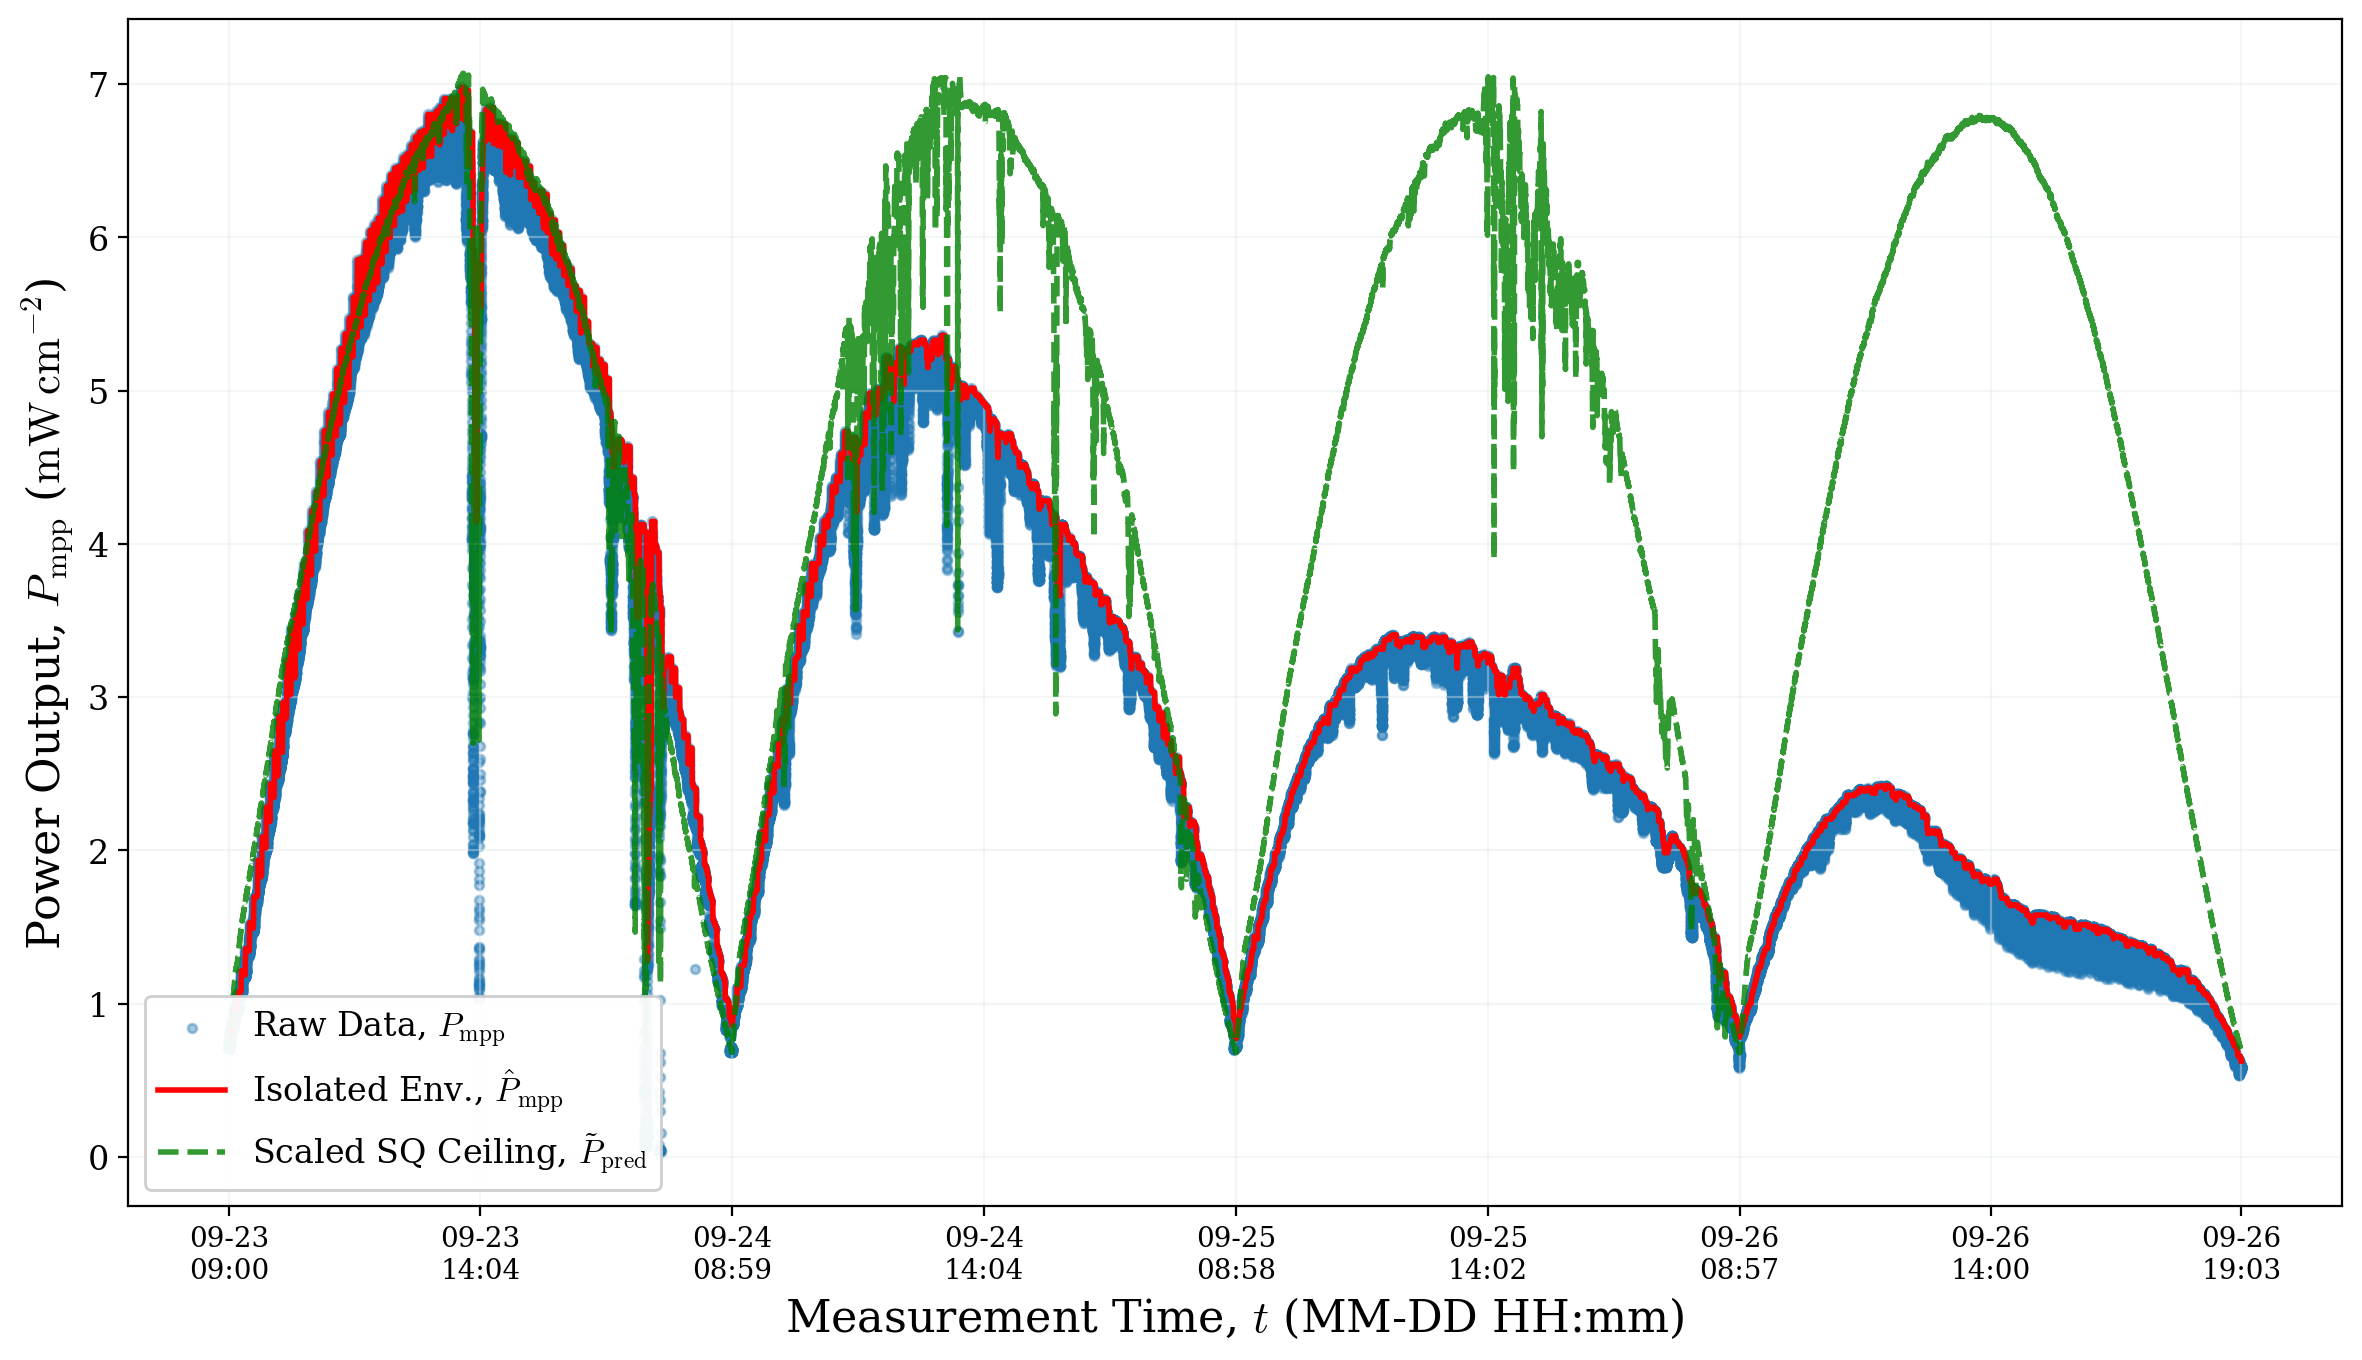

\P12:


/tmp/ipykernel_2669/2747384247.py:87: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_plot = pd.concat([df_plot, nan_rows]).sort_index().reset_index(drop=True)


--> Plot successfully saved to: /content/drive/MyDrive/Colab Notebooks/TFG/plots/temporal_profile_P12.pdf


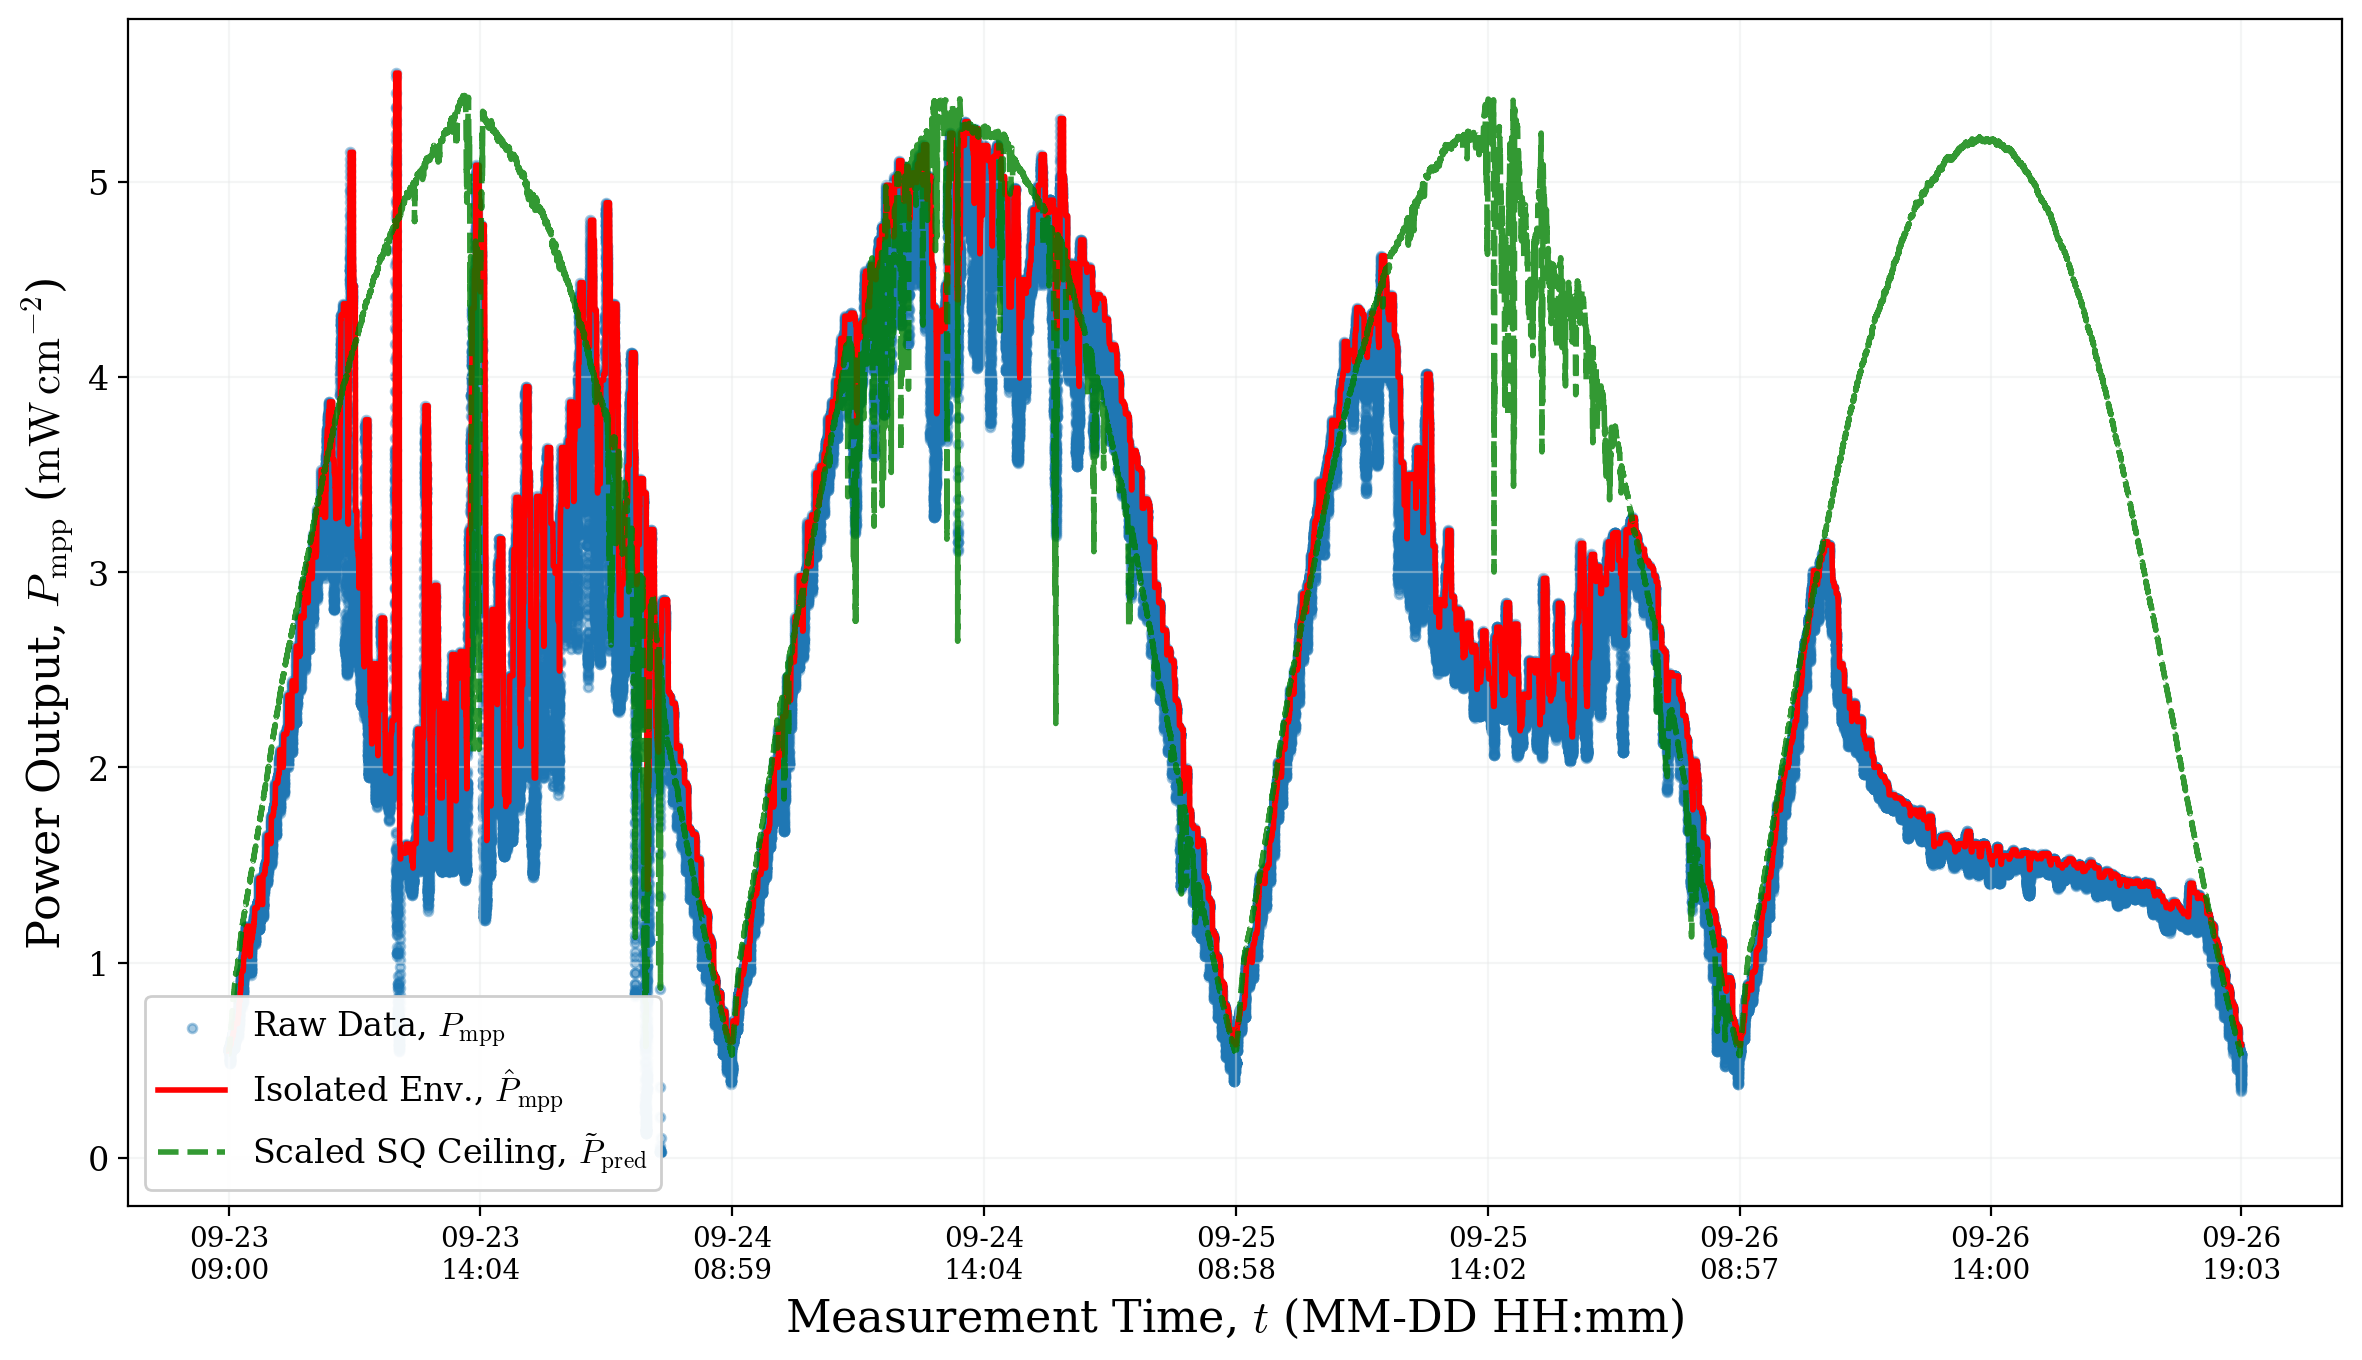

In [13]:
print("M0:")
plot_profile(df_plot_in=df_res_m0, cell_id=0, min_gci=0, min_G_mwcm2=0, min_power=0, isolated_mpp_line=True,
             start_date=pd.to_datetime('2025-09-23'), end_date=pd.to_datetime('2025-09-27'),
             color=False, temp=False, feature=None, theoretical=True, PR=False, df_window=500)

print("\P12:")
plot_profile(df_plot_in=df_res_p12, cell_id=1, min_gci=0, min_G_mwcm2=0, min_power=0, isolated_mpp_line=True,
             start_date=pd.to_datetime('2025-09-23'), end_date=pd.to_datetime('2025-09-27'),
             color=False, temp=False, feature=None, theoretical=True, PR=False, df_window=500)

Analyzing Hysteresis for cell_id=0 on 2025-09-25...


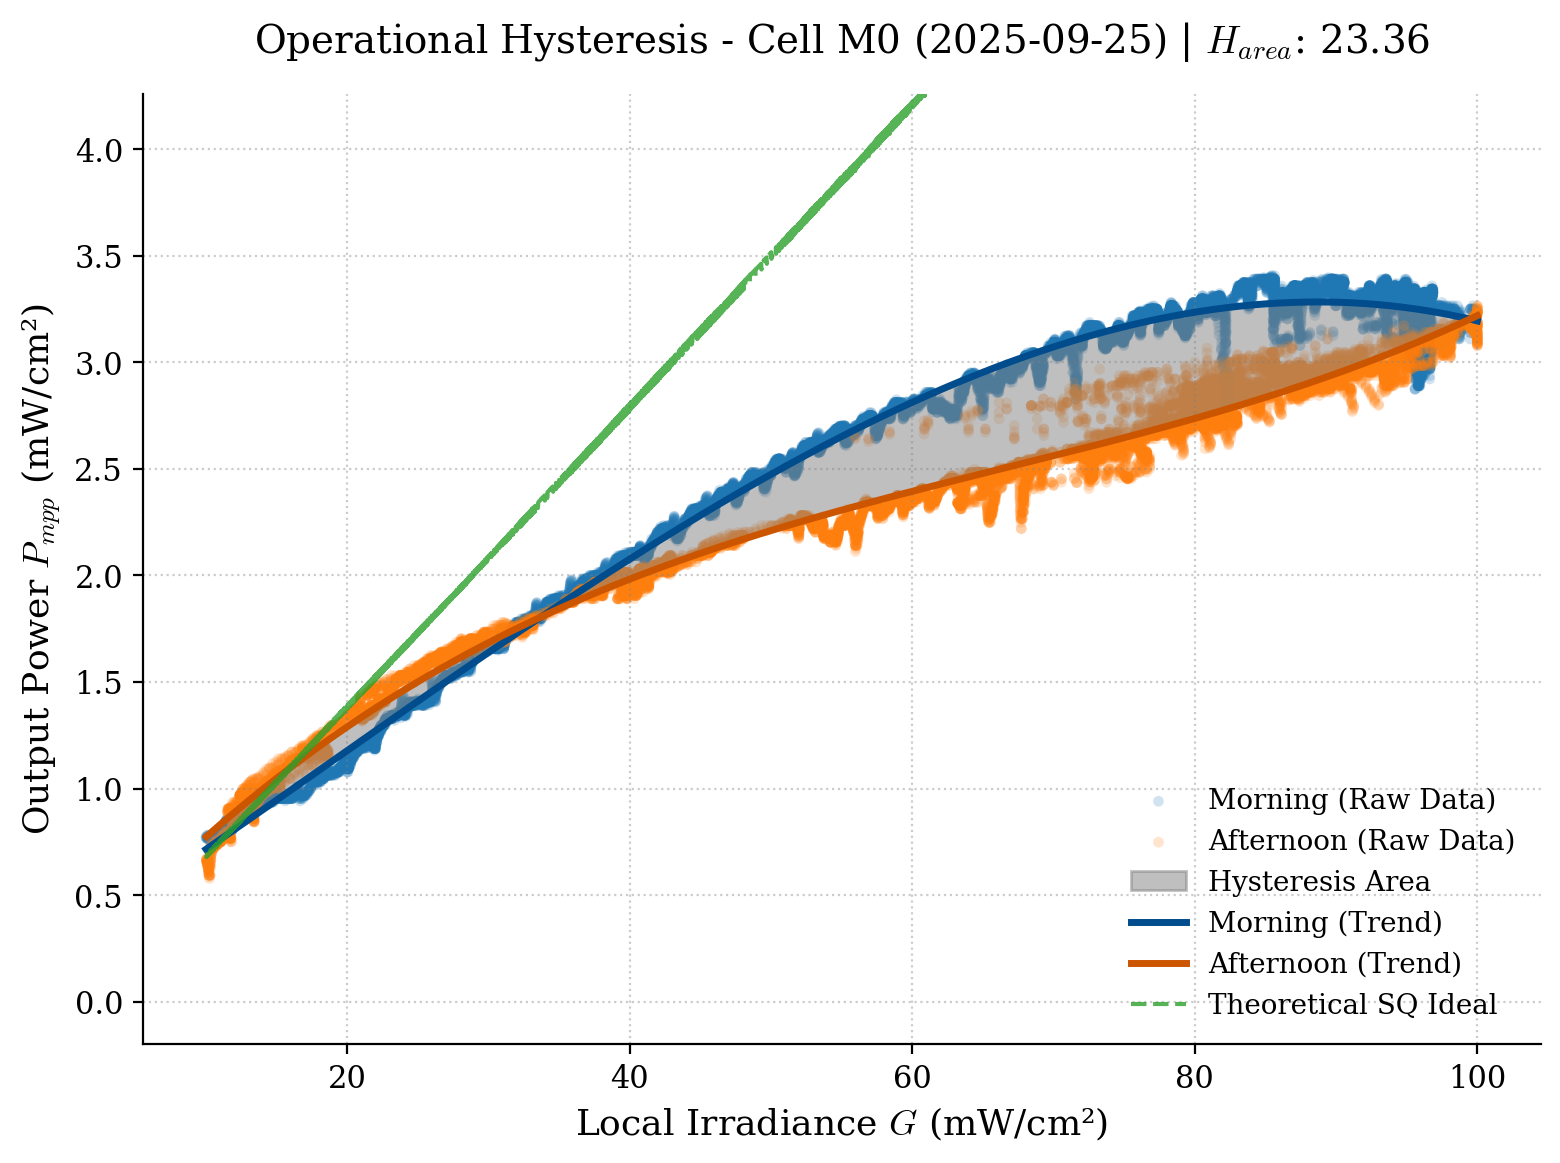

Analyzing Hysteresis for cell_id=0 on 2025-11-08...


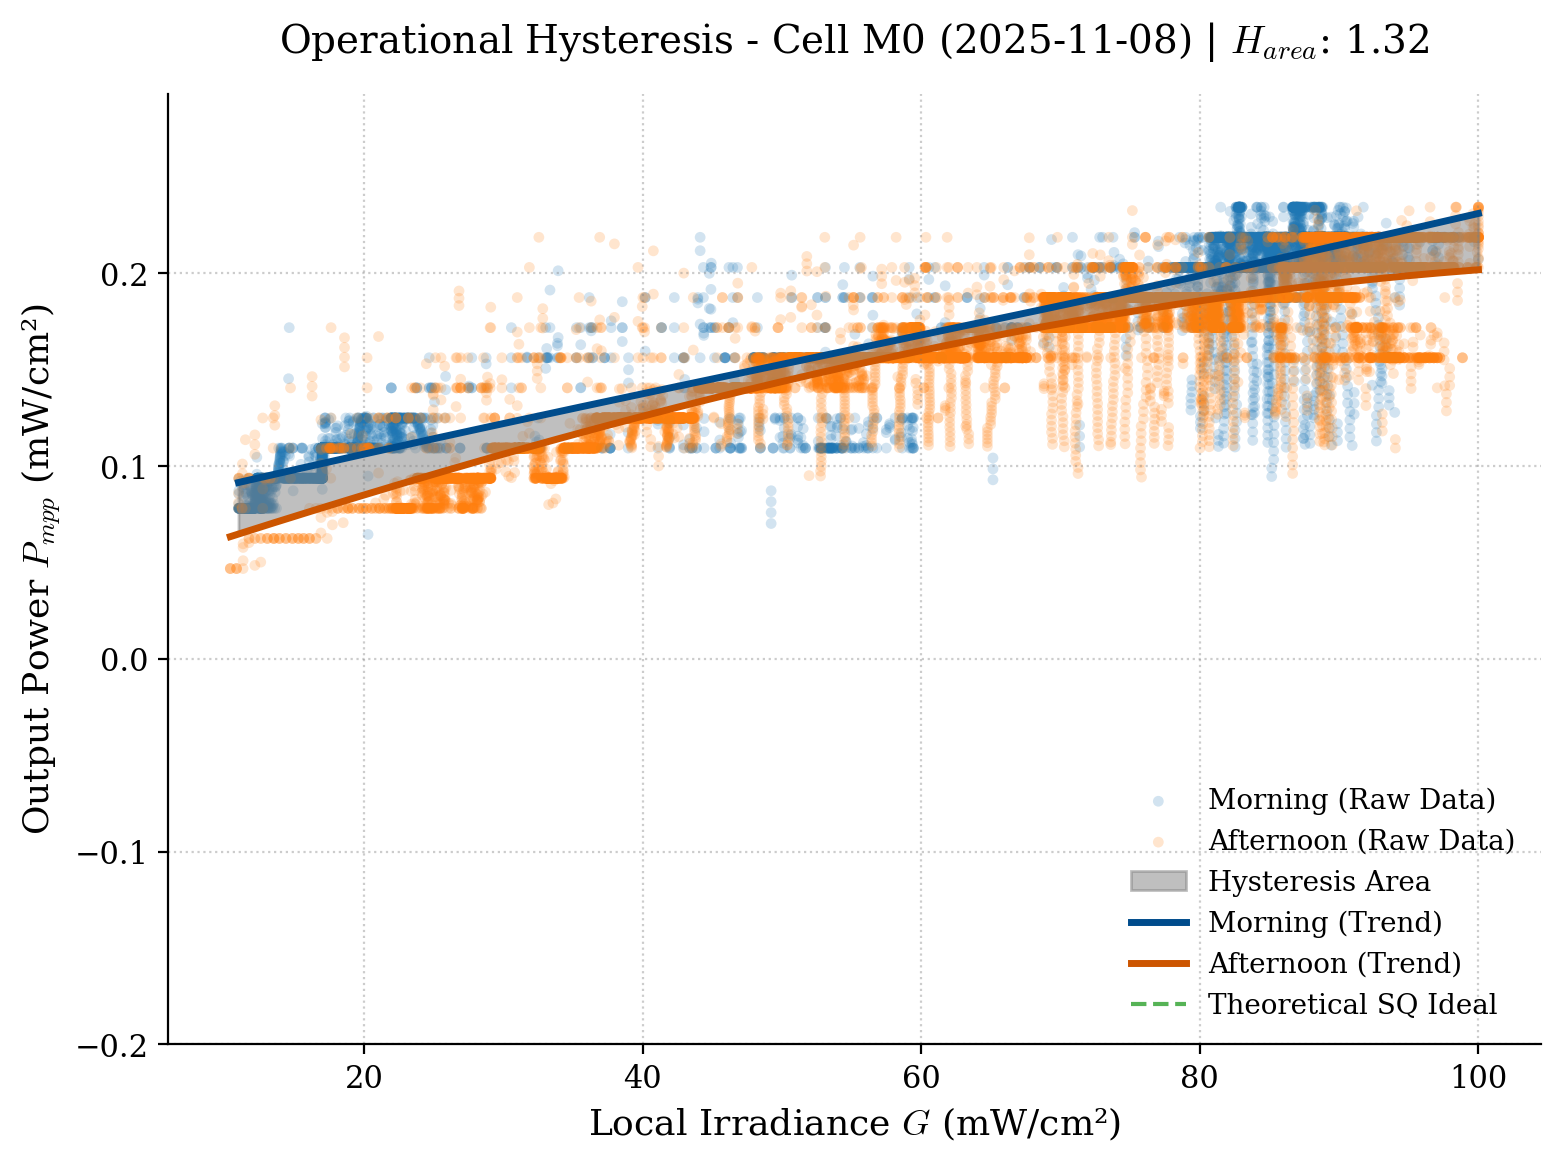

Analyzing Hysteresis for cell_id=1 on 2025-09-25...


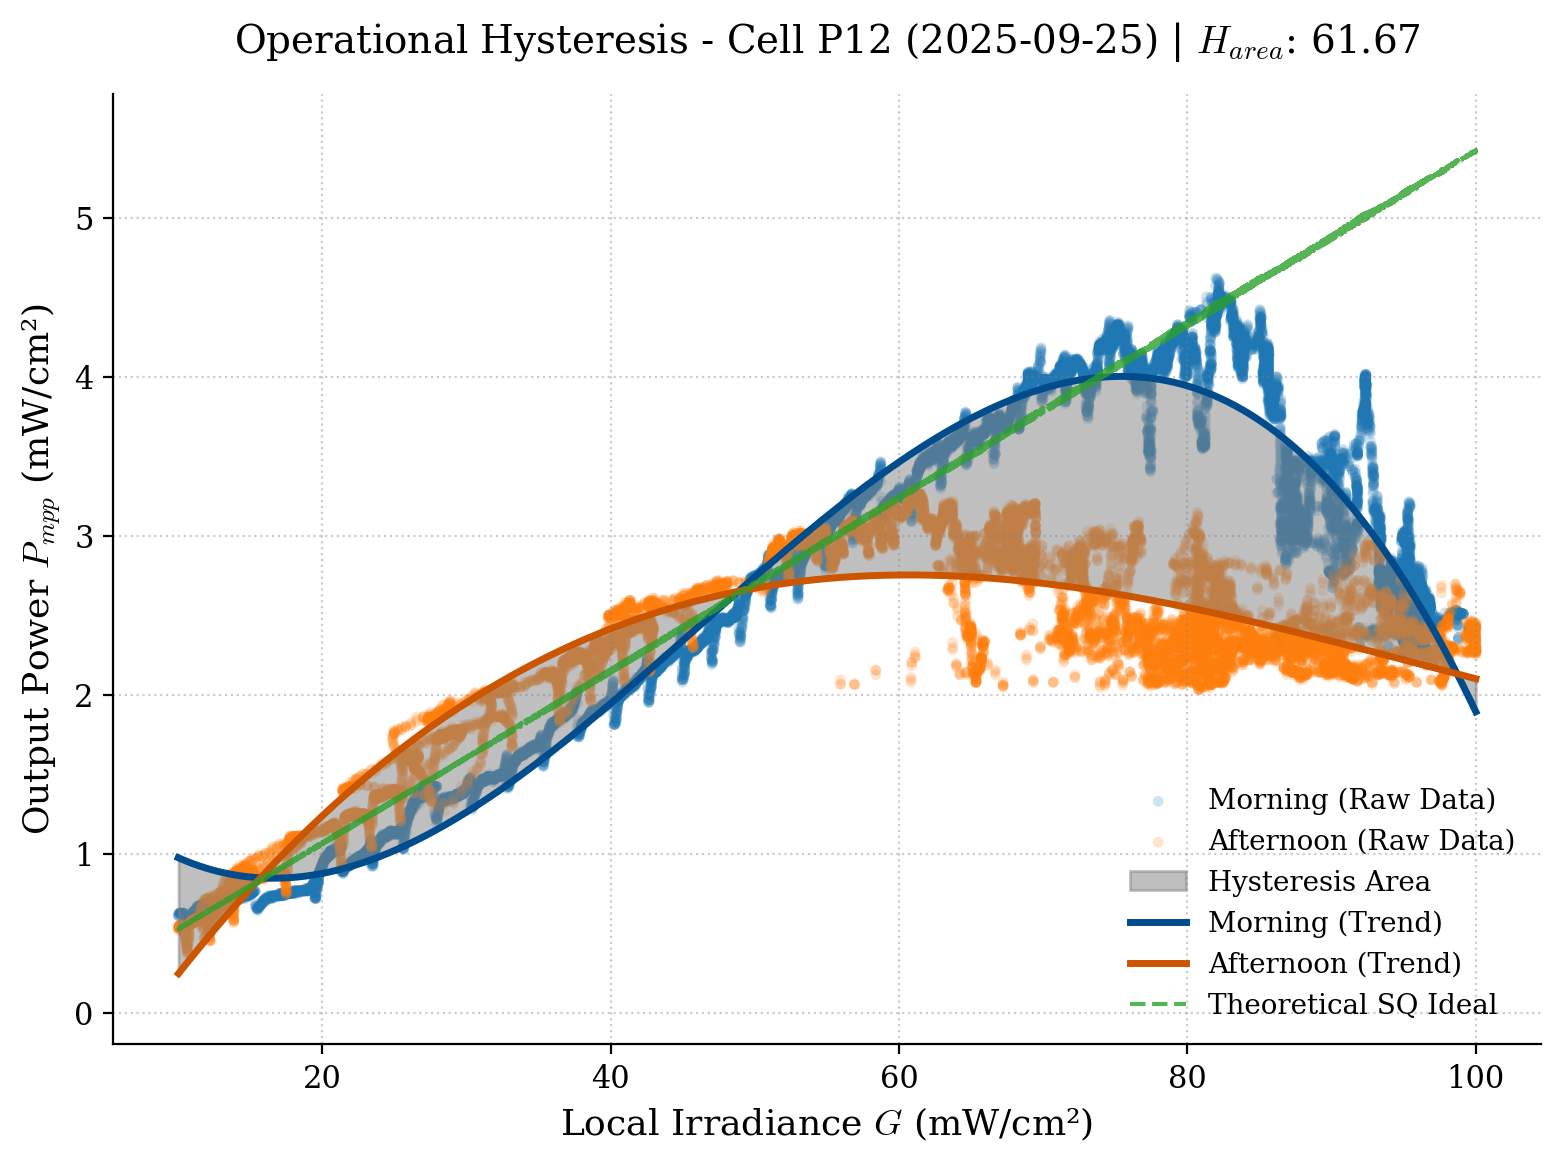

Analyzing Hysteresis for cell_id=1 on 2025-11-08...


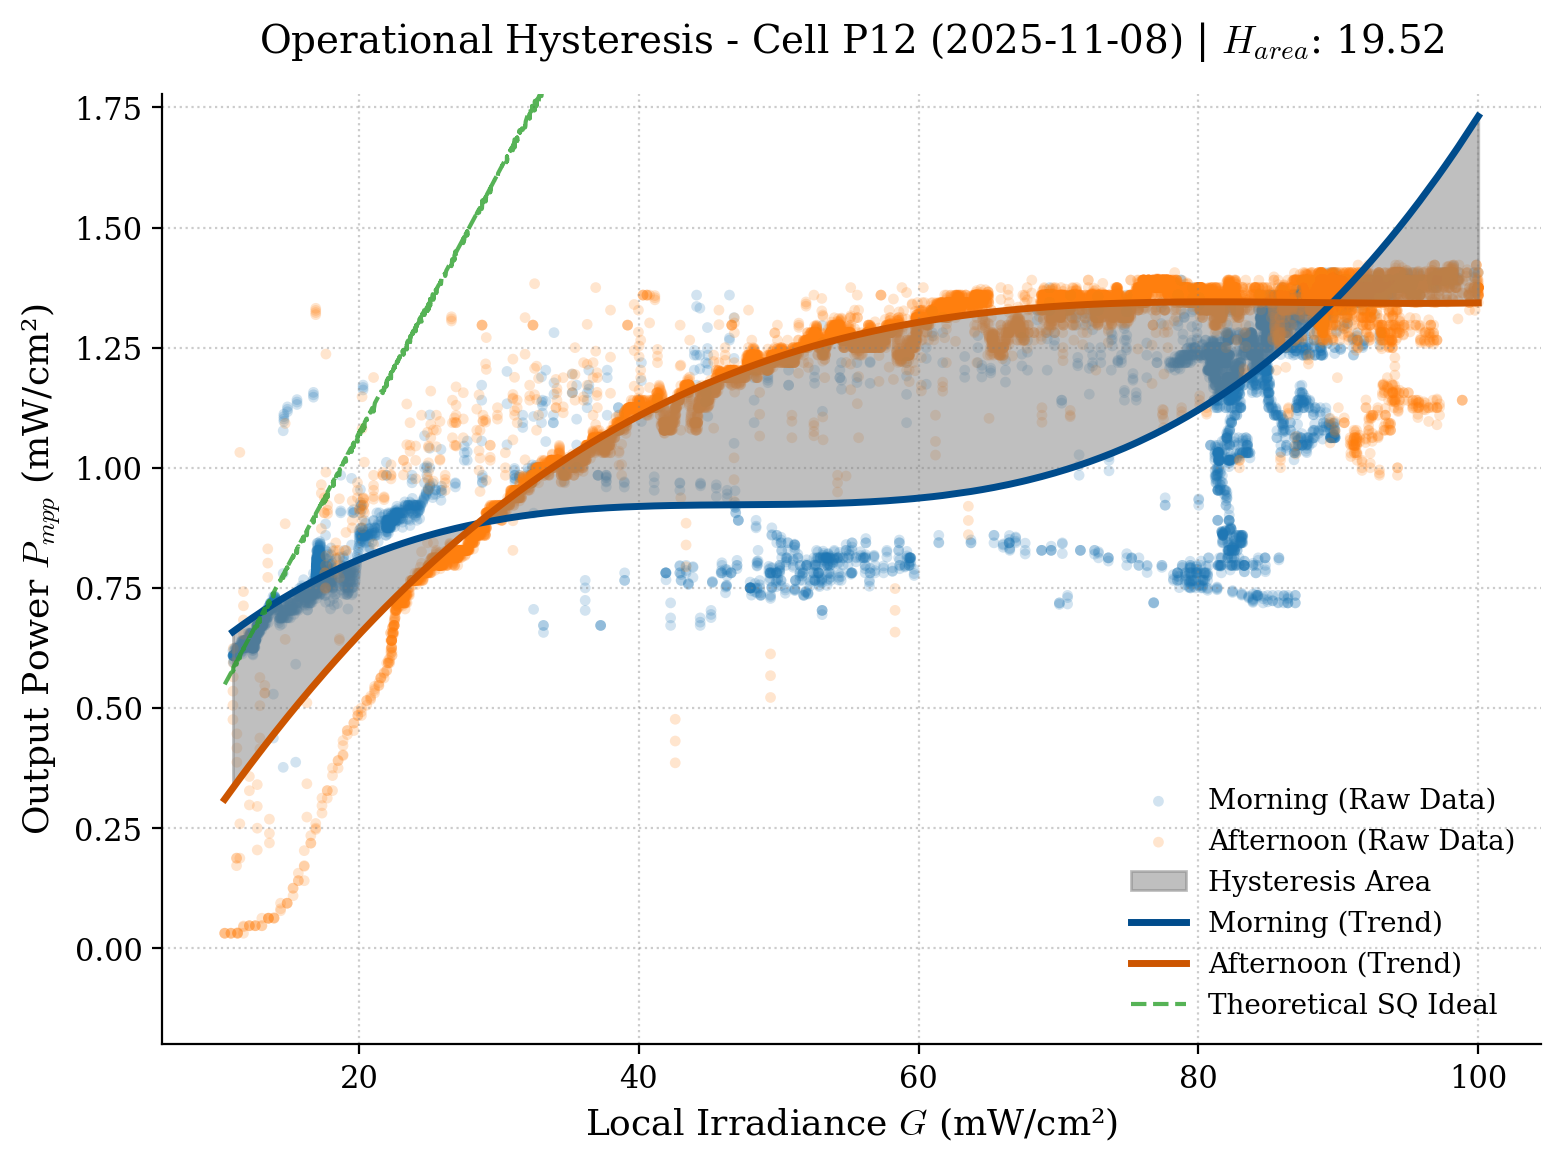


Extracting long-term hysteresis evolution for cell_id=0...


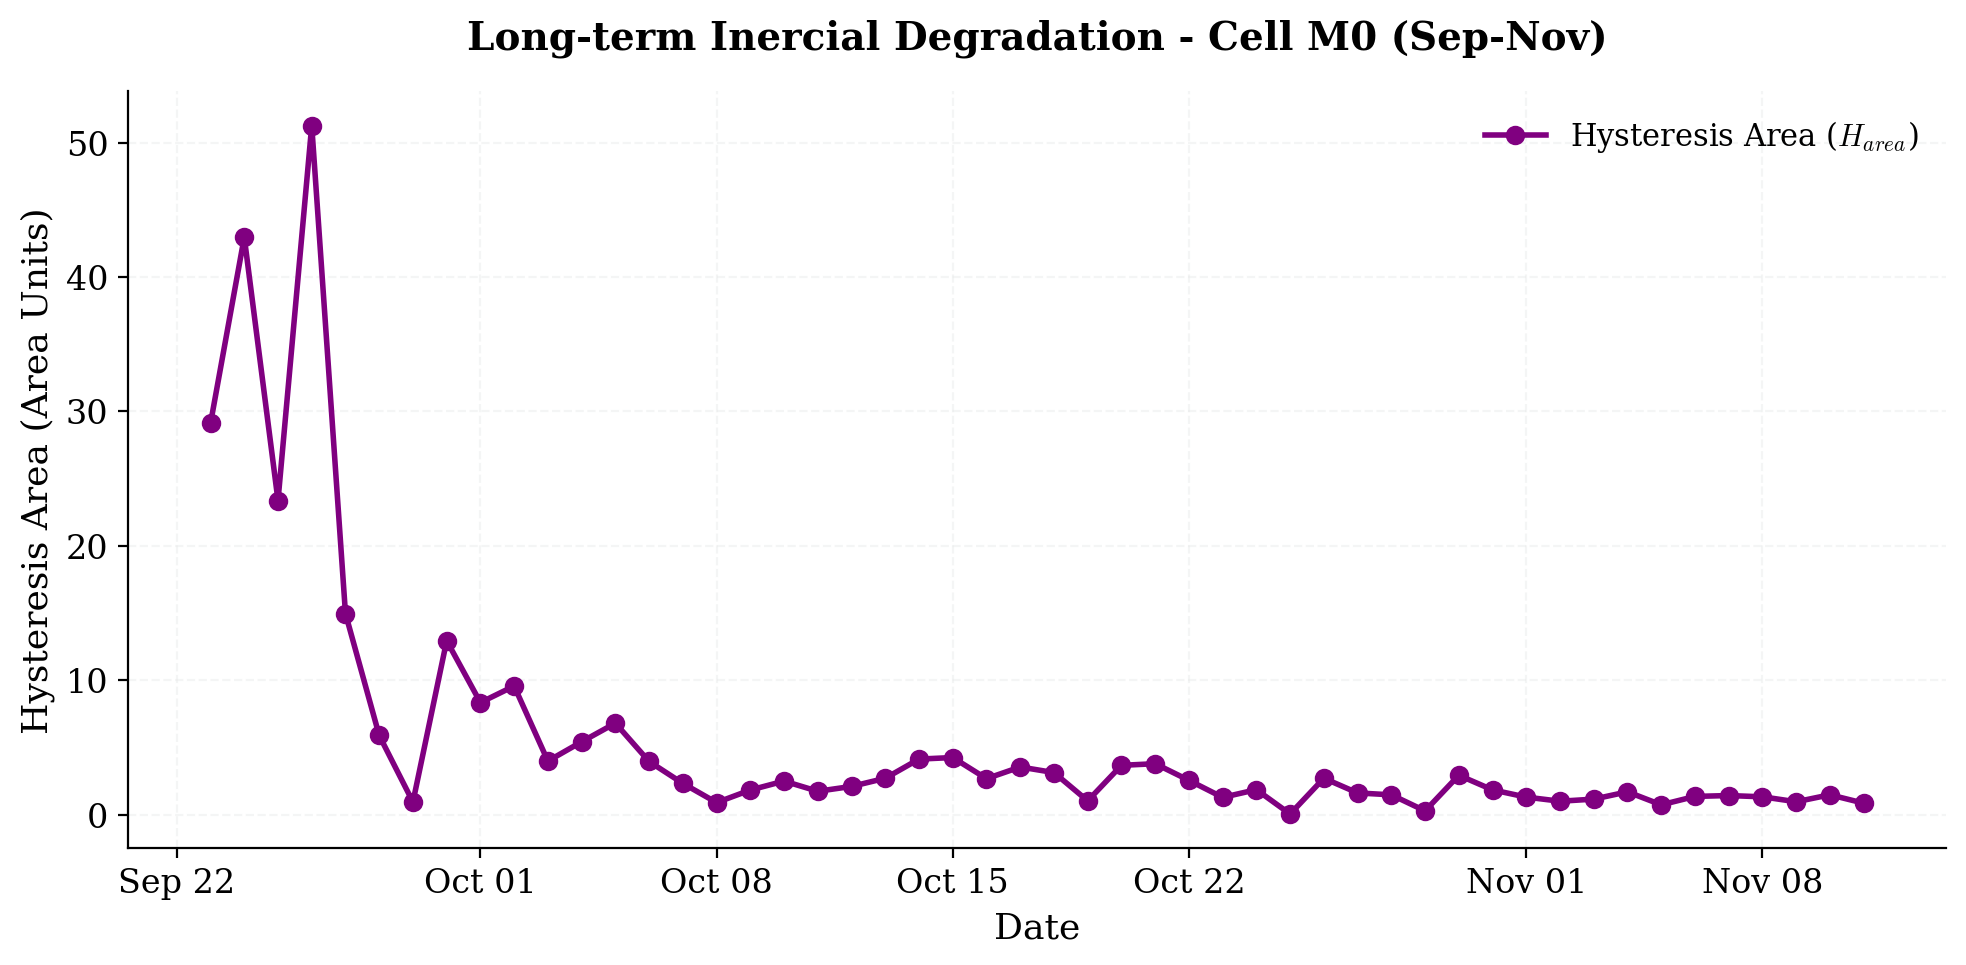


Extracting long-term hysteresis evolution for cell_id=1...


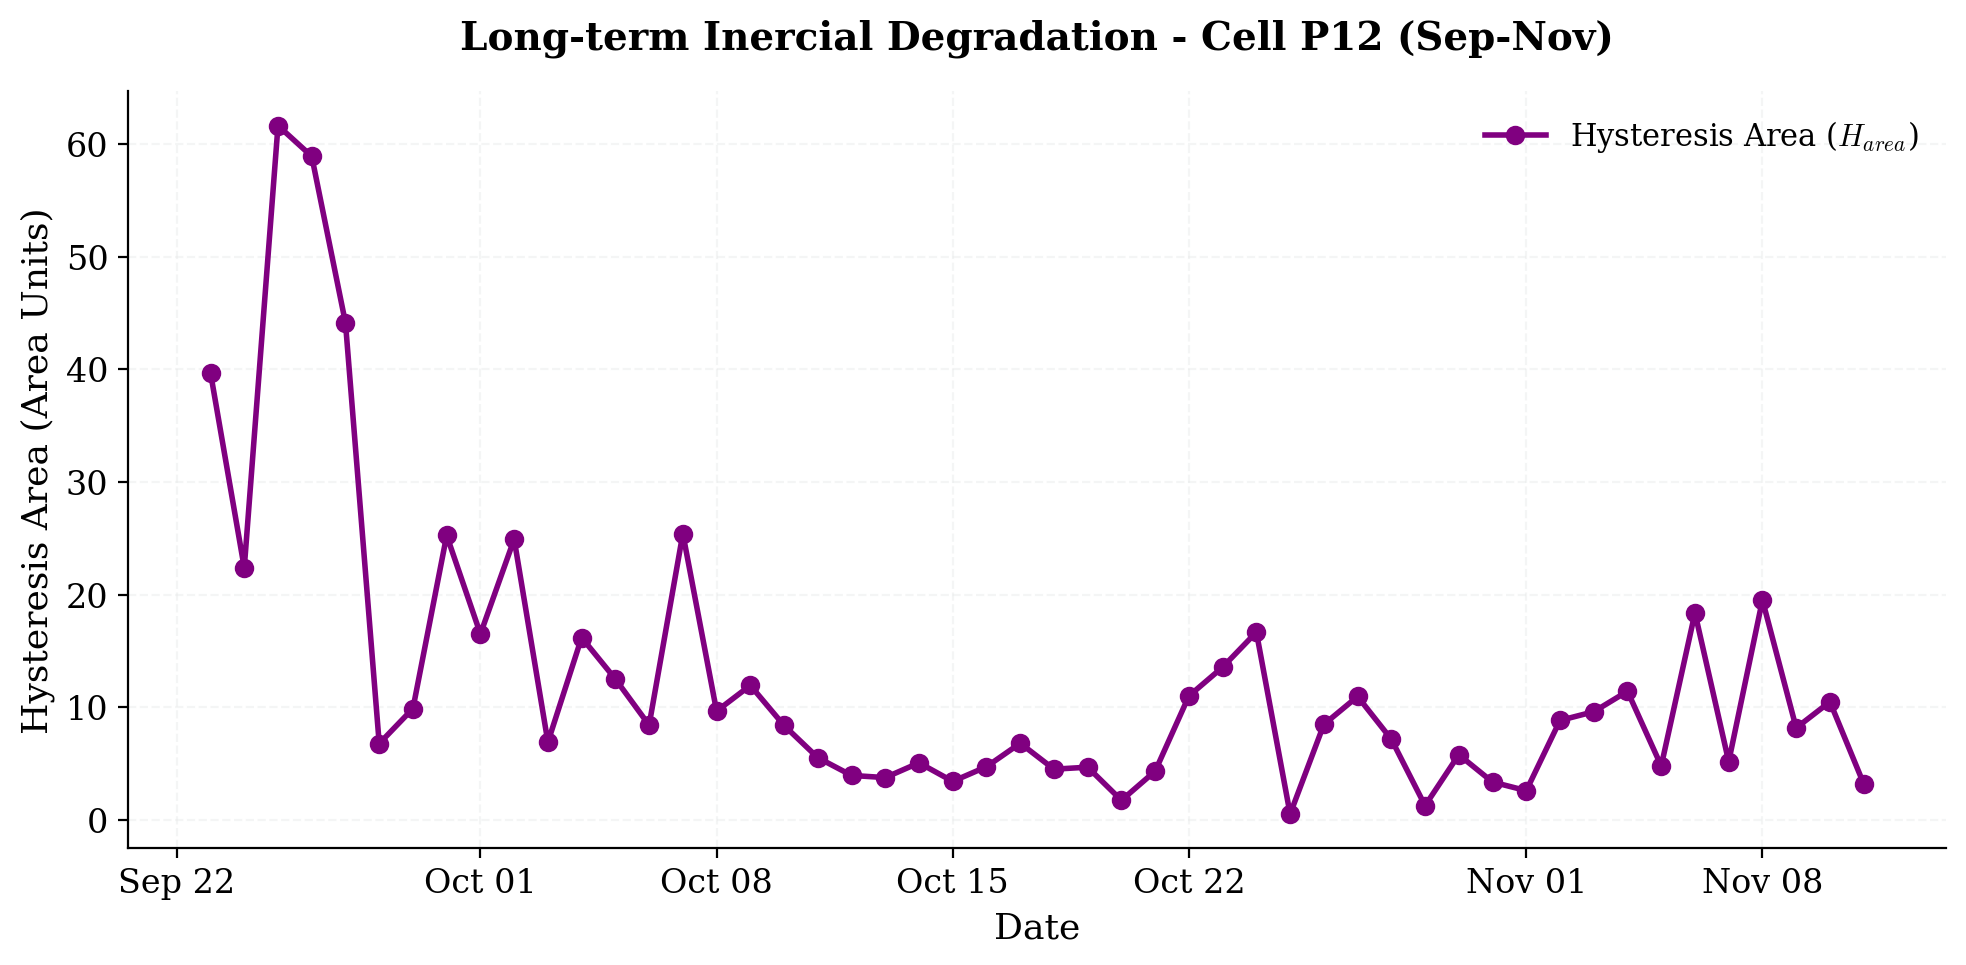

In [14]:
def get_hysteresis_area(df_processed, target_date, cell_id=0, show_plot=True):
    """
    Generates the daily hysteresis plot, calculates the area, and shades the integrated zone.
    """
    if show_plot:
        print(f"Analyzing Hysteresis for cell_id={cell_id} on {target_date}...")

    # 1. Data preparation (Same as before)
    cell_df = df_processed[df_processed['cell_id'] == cell_id].copy()
    cell_name = 'M0' if cell_id == 0 else 'P12'

    if 'time' in cell_df.columns:
        cell_df['time'] = pd.to_datetime(cell_df['time'])
        cell_df.set_index('time', inplace=True)
    elif cell_df.index.name != 'time':
        cell_df.index = pd.to_datetime(cell_df.index)

    try:
        day_data = cell_df.loc[str(target_date)].copy()
    except KeyError:
        return np.nan

    day_data = day_data[day_data['G_mwcm2'] > 5.0]
    if len(day_data) < 20:
        return np.nan

    peak_solar_time = day_data['G_mwcm2'].idxmax()
    morning_data = day_data.loc[:peak_solar_time]
    afternoon_data = day_data.loc[peak_solar_time:]

    morning_sorted = morning_data.sort_values(by='G_mwcm2')
    afternoon_sorted = afternoon_data.sort_values(by='G_mwcm2')

    hysteresis_area = np.nan
    p_m, p_a = None, None
    G_eval = None # Initialize to use later in the plot

    # 2. Calculate polynomials and area
    if len(morning_sorted) > 10 and len(afternoon_sorted) > 10:
        z_m = np.polyfit(morning_sorted['G_mwcm2'], morning_sorted['mpp_mwcm2'], 3)
        p_m = np.poly1d(z_m)

        z_a = np.polyfit(afternoon_sorted['G_mwcm2'], afternoon_sorted['mpp_mwcm2'], 3)
        p_a = np.poly1d(z_a)

        G_min = max(morning_sorted['G_mwcm2'].min(), afternoon_sorted['G_mwcm2'].min())
        G_max = min(morning_sorted['G_mwcm2'].max(), afternoon_sorted['G_mwcm2'].max())

        if G_min < G_max:
            G_eval = np.linspace(G_min, G_max, 1000)
            power_diff = np.abs(p_m(G_eval) - p_a(G_eval))
            hysteresis_area = simpson(power_diff, G_eval)

    # 3. Plotting
    if show_plot:
        fig, ax = plt.subplots(figsize=(8, 6))
        color_morning = '#1f77b4'
        color_afternoon = '#ff7f0e'

        # Original data points
        ax.scatter(morning_data['G_mwcm2'], morning_data['mpp_mwcm2'],
                   color=color_morning, alpha=0.2, s=15, edgecolor='none', label='Morning (Raw Data)')
        ax.scatter(afternoon_data['G_mwcm2'], afternoon_data['mpp_mwcm2'],
                   color=color_afternoon, alpha=0.2, s=15, edgecolor='none', label='Afternoon (Raw Data)')

        # Area shading (Only if it could be calculated)
        if p_m is not None and p_a is not None and G_eval is not None:
            ax.fill_between(G_eval, p_m(G_eval), p_a(G_eval),
                            color='gray', alpha=0.5, label='Hysteresis Area')

        # Trend curves
        if p_m is not None:
            ax.plot(morning_sorted['G_mwcm2'], p_m(morning_sorted['G_mwcm2']),
                    color='#004c8c', linewidth=2.5, label='Morning (Trend)')
        if p_a is not None:
            ax.plot(afternoon_sorted['G_mwcm2'], p_a(afternoon_sorted['G_mwcm2']),
                    color='#cc5500', linewidth=2.5, label='Afternoon (Trend)')

        # Theoretical ideal line
        ideal_sorted = day_data.sort_values(by='G_mwcm2')
        ax.plot(ideal_sorted['G_mwcm2'], ideal_sorted['mpp_pred_mwcm2'],
                color='#2ca02c', linewidth=1.5, linestyle='--', alpha=0.8, label='Theoretical SQ Ideal')

        # Plot aesthetics
        max_real_power = day_data['mpp_mwcm2'].max()
        ax.set_ylim(-0.2, max_real_power * 1.25)
        ax.set_xlabel('Local Irradiance $G$ (mW/cm²)', fontsize=13)
        ax.set_ylabel('Output Power $P_{mpp}$ (mW/cm²)', fontsize=13)

        area_text = f"| $H_{{area}}$: {hysteresis_area:.2f}" if not np.isnan(hysteresis_area) else "| $H_{{area}}$: N/A"
        ax.set_title(f'Operational Hysteresis - Cell {cell_name} ({target_date}) {area_text}', fontsize=14, pad=15)

        ax.tick_params(axis='both', labelsize=11)
        ax.grid(True, alpha=0.4, linestyle=':', color='gray')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(loc='lower right', fontsize=10, frameon=False)

        plt.tight_layout()
        plt.show()

    return hysteresis_area

def plot_long_term_hysteresis_evolution(df_processed, cell_id=0, start_date='2025-09-23', end_date='2025-11-11'):
    """
    Iterates over a date period, extracts the daily hysteresis area,
    and generates a long-term evolution plot.
    """
    print(f"\nExtracting long-term hysteresis evolution for cell_id={cell_id}...")

    # Generate date range
    date_range = pd.date_range(start=start_date, end=end_date)

    areas = []
    valid_dates = []

    # Collect the metric day by day without printing plots
    for single_date in date_range:
        date_str = single_date.strftime('%Y-%m-%d')
        area = get_hysteresis_area(df_processed, target_date=date_str, cell_id=cell_id, show_plot=False)

        if not np.isnan(area):
            areas.append(area)
            valid_dates.append(single_date)

    # Create DataFrame with the results
    df_areas = pd.DataFrame({'Date': valid_dates, 'H_area': areas})
    df_areas.set_index('Date', inplace=True)

    cell_name = 'M0' if cell_id == 0 else 'P12'

    # Plot the evolution
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(df_areas.index, df_areas['H_area'], marker='o', linestyle='-', color='purple',
            linewidth=2, markersize=6, label='Hysteresis Area ($H_{area}$)')

    # Add linear trend line
    # if len(df_areas) > 2:
    #     x_num = mdates.date2num(df_areas.index)
    #     z = np.polyfit(x_num, df_areas['H_area'], 1)
    #     p = np.poly1d(z)
    #     ax.plot(df_areas.index, p(x_num), color='red', linestyle='--', alpha=0.7, label='Degradation Trend')

    ax.set_xlabel('Date', fontsize=13)
    ax.set_ylabel('Hysteresis Area (Area Units)', fontsize=13)
    ax.set_title(f'Long-term Inercial Degradation - Cell {cell_name} (Sep-Nov)', fontsize=14, fontweight='bold', pad=15)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=0)

    ax.grid(True, alpha=0.4, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper right', fontsize=11, frameon=False)

    plt.tight_layout()
    plt.show()

    return df_areas

# 1. Test a single day to see that the title includes the Area:
area_m0_test = get_hysteresis_area(df_res_m0, target_date='2025-09-25', cell_id=0, show_plot=True)
area_m0_test = get_hysteresis_area(df_res_m0, target_date='2025-11-08', cell_id=0, show_plot=True)
area_p12_test = get_hysteresis_area(df_res_p12, target_date='2025-09-25', cell_id=1, show_plot=True)
area_p12_test = get_hysteresis_area(df_res_p12, target_date='2025-11-08', cell_id=1, show_plot=True)

# 2. Calculate and plot the evolution for the 50 days:
df_evolution_m0 = plot_long_term_hysteresis_evolution(df_res_m0, cell_id=0, start_date='2025-09-23', end_date='2025-11-11')
df_evolution_p12 = plot_long_term_hysteresis_evolution(df_res_p12, cell_id=1, start_date='2025-09-23', end_date='2025-11-11')